# 04 · Multi-tier evaluation: Train vs Test

| Tier | Metrics | Unit |
|---|---|---|
| 1 Gram | Accuracy, Sensitivity, Specificity, PPV, NPV, AUC, F1 | well (primary), isolate (secondary) |
| 2 Growth | same | well |
| 3 MIC | EA, AA, CA, VME, ME, mE | Gram-positive isolate × drug series, **end-to-end** (an isolate wrongly called Gram Negative gets no MIC and counts as a failure) |

**Acceptance criteria (Test):** every ML metric ≥ 0.92; EA, AA, CA ≥ 0.92; VME < 2%; ME ≤ 3% (FDA AST guidance).

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/gram-id-ast-ml


In [2]:
# Rebuild the isolate-grouped splits if they are missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
# Train everything once if the saved cascades are missing (about 6 minutes)
if not all(cfg.cascade_file(m).exists() for m in cfg.MODEL_NAMES):
    from src.features import build_features as bf
    from src.models import train_model as tm
    bf.run(); tm.run(); plt.close("all")
elif not cfg.SELECTED_FEATURES_FILE.exists():
    from src.features import build_features as bf
    bf.run(); plt.close("all")

from src.models import evaluate_model as em
from src.models.train_model import load_cascades
from src.data.make_dataset import load_split, load_breakpoints
cascades, bp = load_cascades(), load_breakpoints()
sets = {"Train": load_split("train"), "Test": load_split("test")}
ml, t3, series_out, probs = em.evaluate(cascades, sets, bp)

## 1. Train vs Test comparison table

In [3]:
display(Markdown(em.comparison_markdown(ml, t3)))

| Tier | Metric | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test | Transformer Train | Transformer Test |
|---|---|---:|---:|---:|---:|---:|---:|
| Tier 1 Gram | Accuracy | 0.980 | 0.973 | 0.972 | 0.968 | 0.968 | 0.968 |
| Tier 1 Gram | Sensitivity | 0.967 | 0.966 | 0.971 | 0.971 | 0.952 | 0.959 |
| Tier 1 Gram | Specificity | 0.995 | 0.981 | 0.973 | 0.963 | 0.987 | 0.980 |
| Tier 1 Gram | PPV | 0.995 | 0.985 | 0.977 | 0.971 | 0.989 | 0.983 |
| Tier 1 Gram | NPV | 0.961 | 0.959 | 0.965 | 0.963 | 0.945 | 0.950 |
| Tier 1 Gram | AUC | 0.999 | 0.996 | 0.997 | 0.994 | 0.997 | 0.994 |
| Tier 1 Gram | F1 | 0.981 | 0.975 | 0.974 | 0.971 | 0.970 | 0.971 |
| Tier 2 Growth | Accuracy | 0.994 | 0.985 | 0.989 | 0.983 | 0.990 | 0.979 |
| Tier 2 Growth | Sensitivity | 0.996 | 0.989 | 0.990 | 0.987 | 0.992 | 0.983 |
| Tier 2 Growth | Specificity | 0.992 | 0.980 | 0.987 | 0.979 | 0.987 | 0.975 |
| Tier 2 Growth | PPV | 0.993 | 0.983 | 0.990 | 0.982 | 0.989 | 0.978 |
| Tier 2 Growth | NPV | 0.995 | 0.987 | 0.987 | 0.985 | 0.991 | 0.980 |
| Tier 2 Growth | AUC | 1.000 | 0.999 | 0.999 | 0.998 | 0.999 | 0.999 |
| Tier 2 Growth | F1 | 0.994 | 0.986 | 0.990 | 0.984 | 0.991 | 0.981 |
| Tier 3 MIC | EA | 0.997 | 1.000 | 0.995 | 1.000 | 0.992 | 1.000 |
| Tier 3 MIC | AA | 0.975 | 0.949 | 0.948 | 0.970 | 0.948 | 0.899 |
| Tier 3 MIC | CA | 0.989 | 0.980 | 0.986 | 1.000 | 0.986 | 0.980 |
| Tier 3 MIC | VME | 0.00% | 0.00% | 0.00% | 0.00% | 0.00% | 0.00% |
| Tier 3 MIC | ME | 0.48% | 0.00% | 0.96% | 0.00% | 0.96% | 0.00% |
| Tier 3 MIC | mE | 0.82% | 2.02% | 0.82% | 0.00% | 0.82% | 2.02% |

In [4]:
ml[ml.Tier == "Tier 1 Gram (isolate)"][["Model", "Set", "Accuracy", "Sensitivity", "Specificity", "AUC", "FP", "FN"]]

,Model,Set,Accuracy,Sensitivity,Specificity,AUC,FP,FN
1,XGBoost,Train,1.0,1.0,1.0,1.0,0,0
4,XGBoost,Test,1.0,1.0,1.0,1.0,0,0
7,SVM-RBF,Train,1.0,1.0,1.0,1.0,0,0
10,SVM-RBF,Test,1.0,1.0,1.0,1.0,0,0
13,Transformer,Train,1.0,1.0,1.0,1.0,0,0
16,Transformer,Test,1.0,1.0,1.0,1.0,0,0


In [5]:
t3[["Model", "Set", "EA", "AA", "CA", "VME", "ME", "mE", "n_series", "n_ref_R", "n_VME", "n_ME", "series_without_call"]].round(4)

,Model,Set,EA,AA,CA,VME,ME,mE,n_series,n_ref_R,n_VME,n_ME,series_without_call
0,XGBoost,Train,0.9973,0.9755,0.9891,0.0,0.0048,0.0082,367,139,0,1,0
1,XGBoost,Test,1.0000,0.9495,0.9798,0.0,0.0000,0.0202,99,40,0,0,0
2,SVM-RBF,Train,0.9946,0.9482,0.9864,0.0,0.0096,0.0082,367,139,0,2,0
3,SVM-RBF,Test,1.0000,0.9697,1.0000,0.0,0.0000,0.0000,99,40,0,0,0
4,Transformer,Train,0.9918,0.9482,0.9864,0.0,0.0096,0.0082,367,139,0,2,0
5,Transformer,Test,1.0000,0.8990,0.9798,0.0,0.0000,0.0202,99,40,0,0,0


## 2. Acceptance criteria

In [6]:
acc = em.acceptance(ml, t3)
print(f"{int(acc.Pass.sum())} of {len(acc)} criteria met on Test")
acc[~acc.Pass] if (~acc.Pass).any() else "all criteria met"

56 of 57 criteria met on Test


,Model,Tier,Metric,Test value,Criterion,Pass
53,Transformer,Tier 3 MIC,AA,0.89899,>= 0.92,False


In [7]:
acc.pivot_table(index=["Tier", "Metric"], columns="Model", values="Test value").round(4)

Model                             SVM-RBF  Transformer  XGBoost
Tier                 Metric                                    
Tier 1 Gram (well)   AUC           0.9943       0.9937   0.9957
                     Accuracy      0.9675       0.9682   0.9727
                     F1            0.9708       0.9711   0.9753
                     NPV           0.9634       0.9503   0.9585
                     PPV           0.9708       0.9833   0.9845
                     Sensitivity   0.9708       0.9592   0.9662
                     Specificity   0.9634       0.9795   0.9810
Tier 2 Growth (well) AUC           0.9979       0.9986   0.9993
                     Accuracy      0.9831       0.9792   0.9851
                     F1            0.9842       0.9806   0.9861
                     NPV           0.9846       0.9804   0.9874
                     PPV           0.9819       0.9782   0.9831
                     Sensitivity   0.9866       0.9830   0.9891
                     Specificity   0.9791       0.9749   0.9805
Tier 3 MIC           AA            0.9697       0.8990   0.9495
                     CA            1.0000       0.9798   0.9798
                     EA            1.0000       1.0000   1.0000
                     ME            0.0000       0.0000   0.0000
                     VME           0.0000       0.0000   0.0000

## 3. Tier 1 and Tier 2 diagnostics

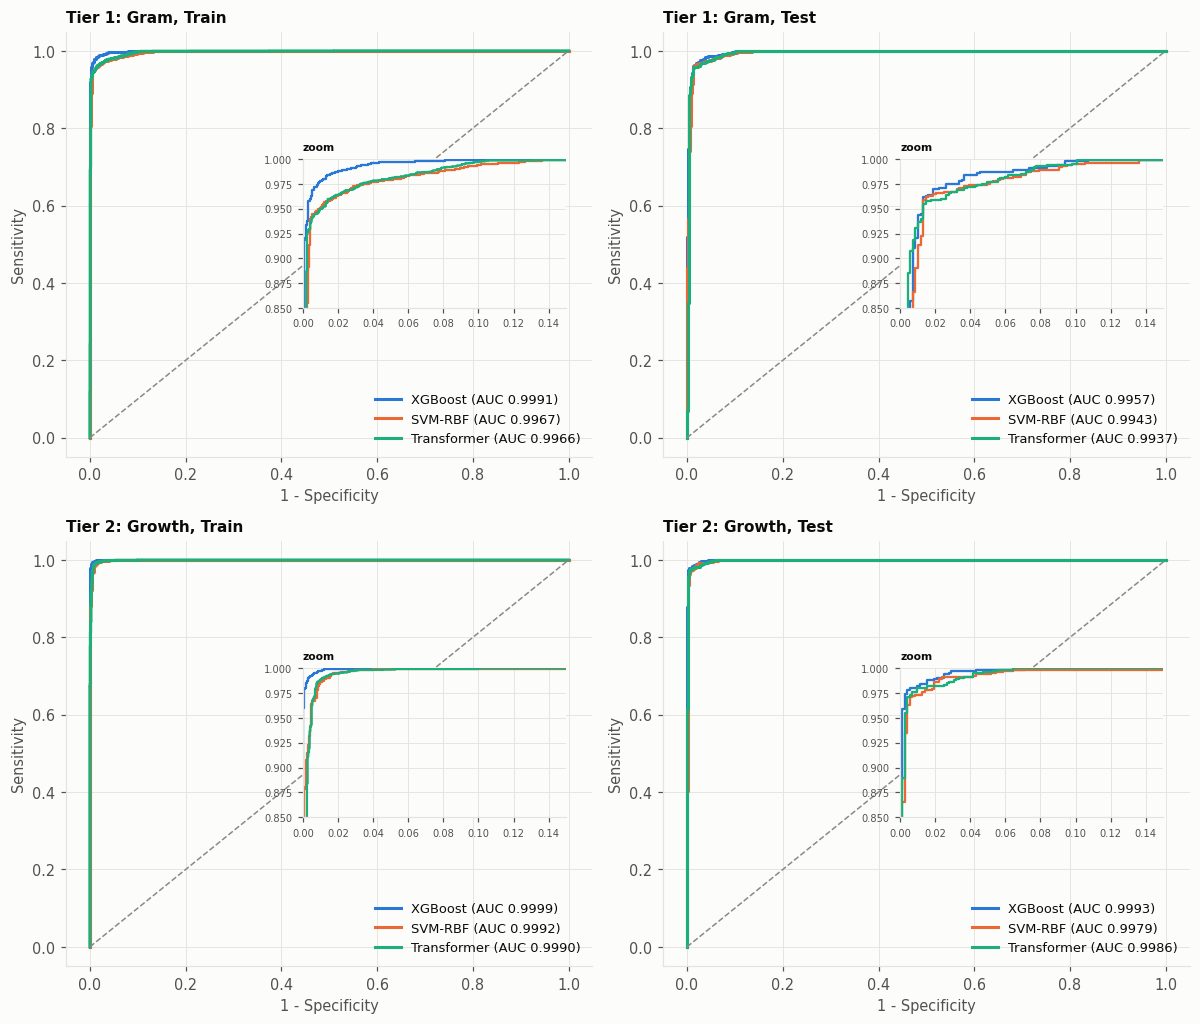

In [8]:
em.plot_roc(probs, sets);

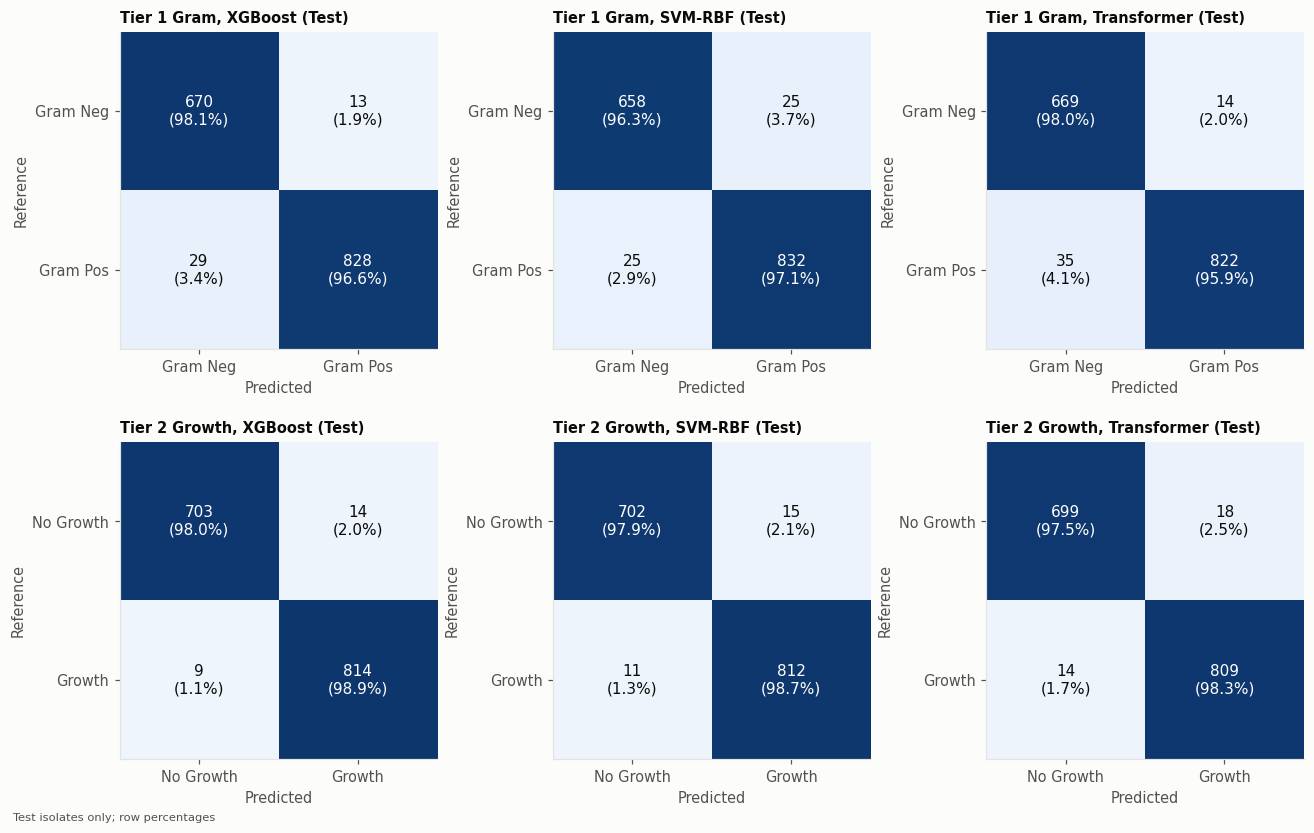

In [9]:
em.plot_confusion(ml);

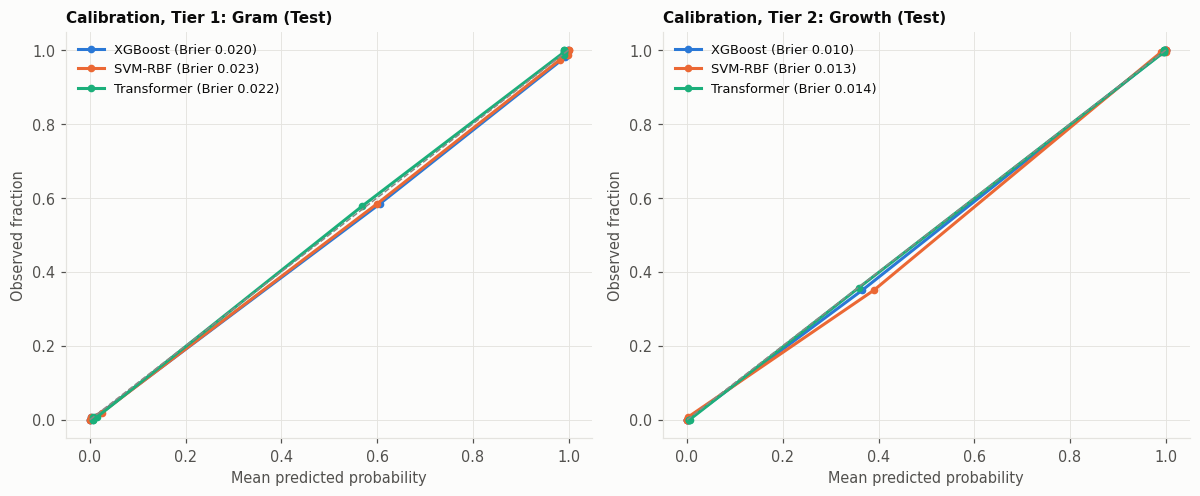

In [10]:
em.plot_calibration(probs, sets);

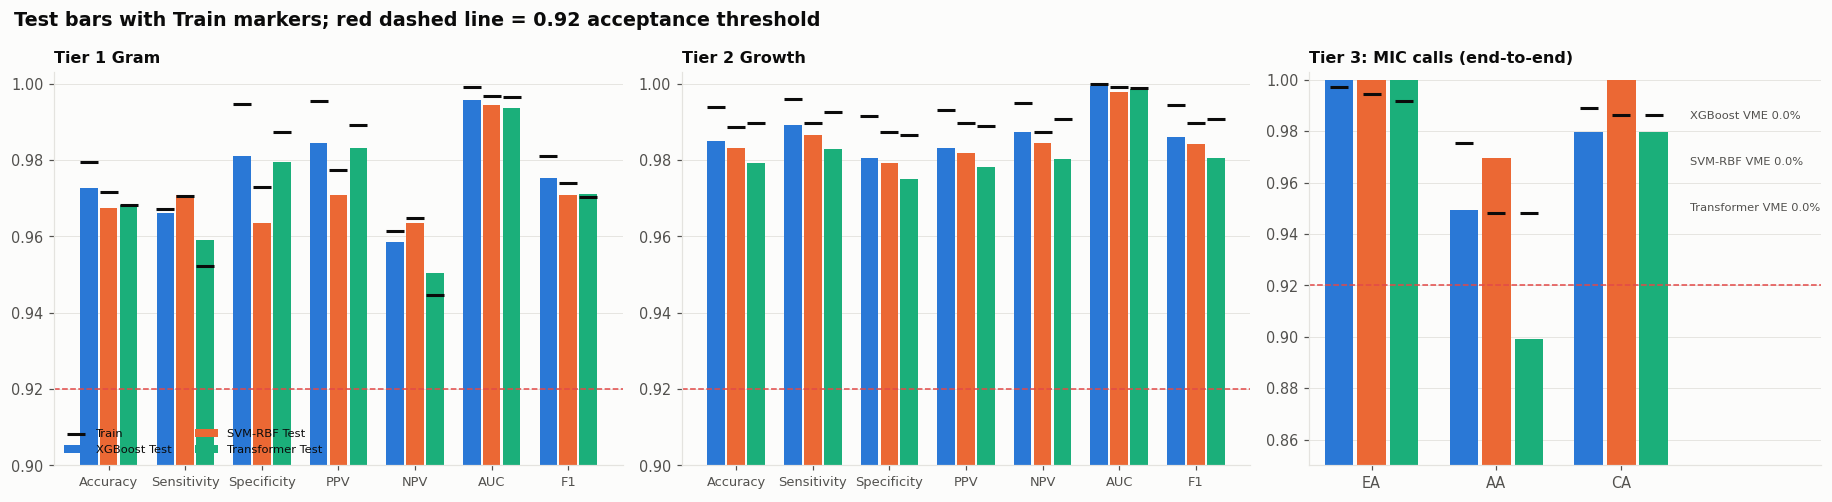

In [11]:
em.plot_metric_comparison(ml, t3);

## 4. Tier 3 MIC agreement

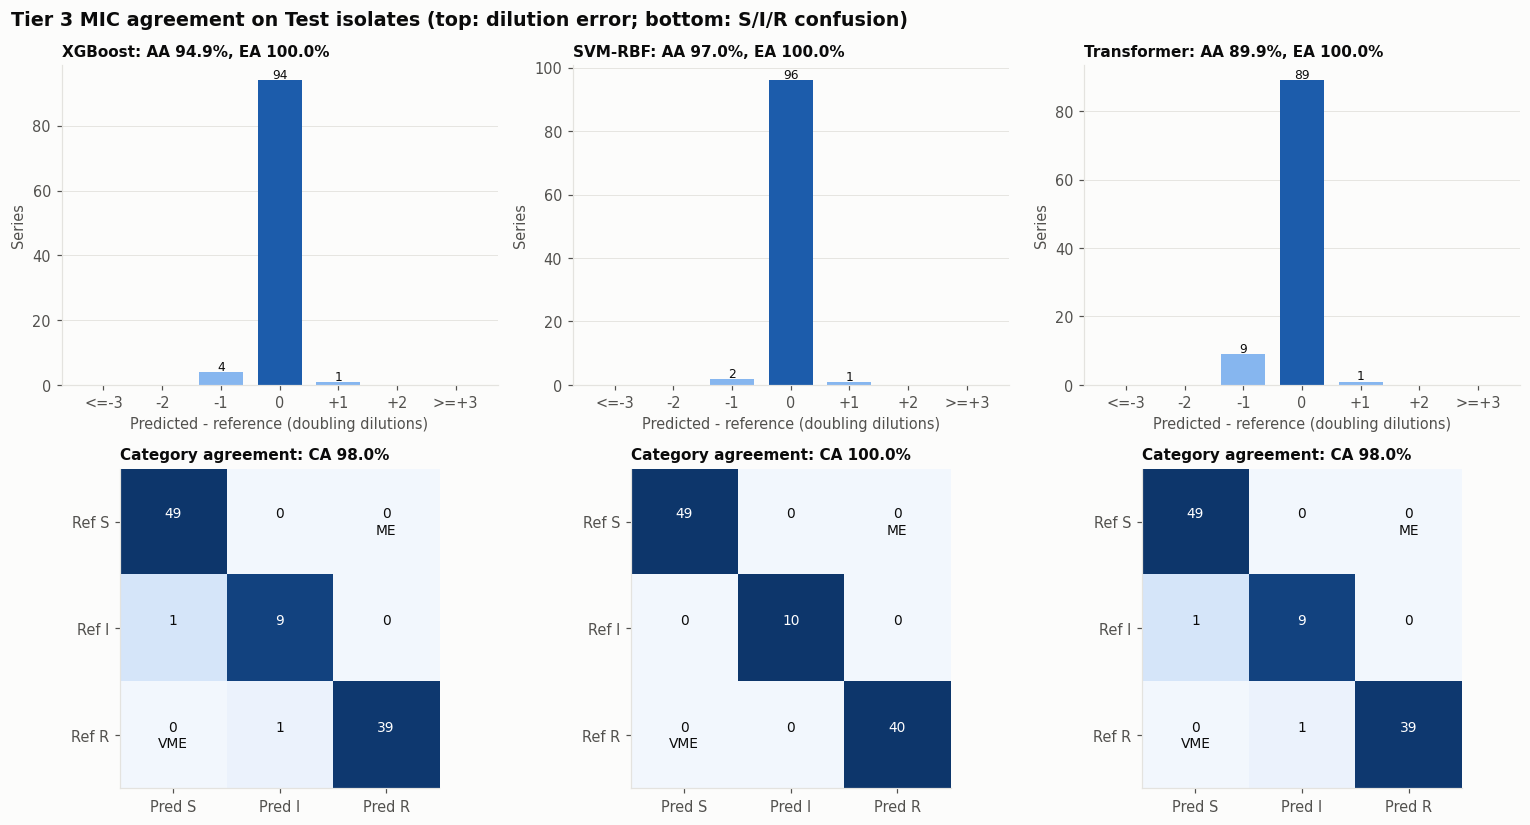

In [12]:
em.plot_mic_agreement(series_out, bp);

Model                                     SVM-RBF  Transformer  XGBoost
Organism                   Antimicrobial                               
Enterococcus faecalis      Ampicillin       1.000        1.000    1.000
                           Ceftriaxone      1.000        1.000    1.000
                           Daptomycin       1.000        1.000    1.000
                           Meropenem        1.000        0.800    1.000
                           Oxacillin        1.000        1.000    1.000
                           Vancomycin       1.000        1.000    1.000
Enterococcus faecium       Ampicillin       1.000        1.000    1.000
                           Ceftriaxone      1.000        1.000    1.000
                           Daptomycin       1.000        1.000    1.000
                           Meropenem        1.000        0.667    1.000
                           Oxacillin        1.000        1.000    1.000
                           Vancomycin       0.667        0.667    0.667
Staphylococcus aureus      Ampicillin       1.000        1.000    1.000
                           Ceftriaxone      1.000        0.600    0.600
                           Daptomycin       1.000        0.833    1.000
                           Meropenem        1.000        0.750    0.750
                           Oxacillin        1.000        1.000    0.667
                           Vancomycin       1.000        1.000    1.000
Staphylococcus epidermidis Ampicillin       0.800        0.800    1.000
                           Ceftriaxone      1.000        1.000    1.000
                           Daptomycin       1.000        1.000    1.000
                           Meropenem        0.800        0.800    1.000
                           Oxacillin        1.000        1.000    1.000
                           Vancomycin       1.000        0.667    1.000

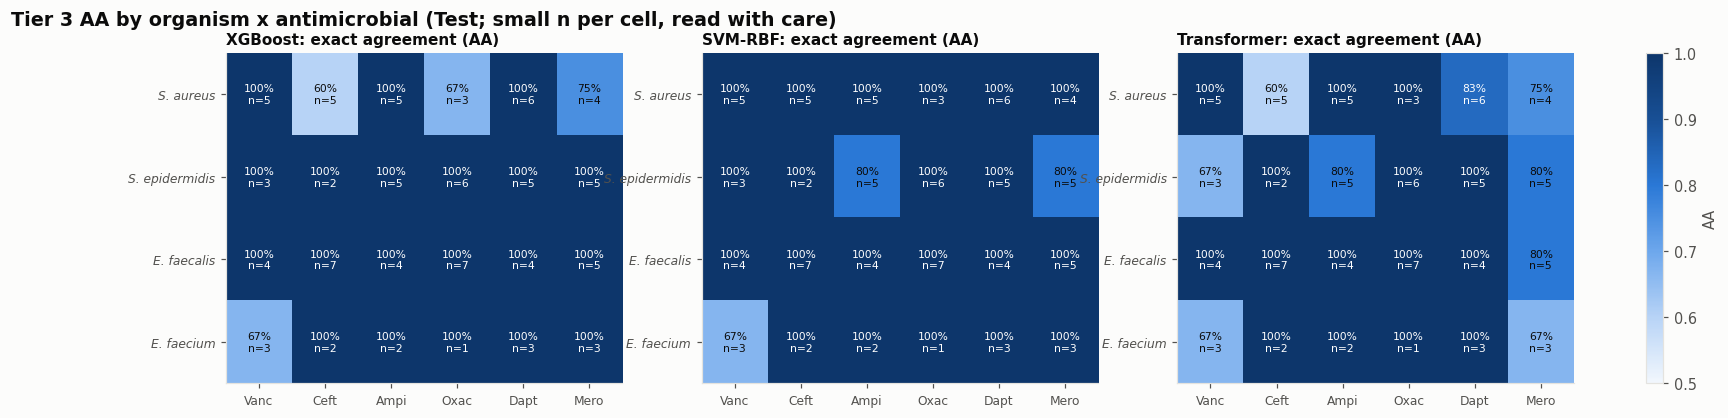

In [13]:
combo = em.per_combo_table(series_out)
em.plot_per_combo(combo)
combo.pivot_table(index=[cfg.ORGANISM, cfg.DRUG], columns="Model", values="AA").round(3)

## 5. Feature importance

,tier1_gram,tier2_growth
Catalase_Positive,0.039,NaN
Cell_Elongation_Index,0.206,0.035
Cell_Morphology_Rods,0.027,NaN
Crystal_Violet_Retention,0.026,NaN
Growth_Fold_Change,NaN,0.324
KOH_String_Test_Positive,0.512,NaN
Mean_Cell_Area_um2,0.141,0.023
OD600_Read,NaN,0.385
Occupied_Area_Fraction,NaN,0.055
Time_to_Detection_h,NaN,0.107


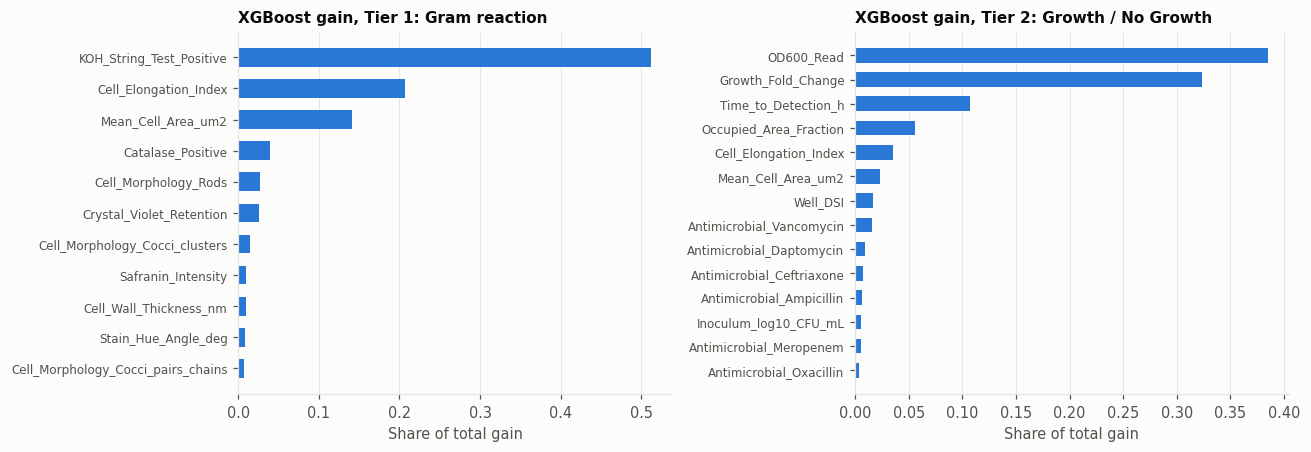

In [14]:
gain = em.plot_xgb_gain(cascades)
pd.DataFrame({t: g.sort_values(ascending=False).head(6).round(3) for t, g in gain.items()})

Model                                  SVM-RBF  Transformer  XGBoost
tier         feature                                                
tier1_gram   Catalase                   0.0092       0.0018   0.0032
             Cell_Elongation_Index      0.0335       0.0343   0.0313
             Cell_Morphology            0.0009      -0.0002   0.0002
             Cell_Wall_Thickness_nm    -0.0000      -0.0005  -0.0001
             Crystal_Violet_Retention   0.0009       0.0002   0.0011
             KOH_String_Test            0.0200       0.0318   0.0283
             Mean_Cell_Area_um2         0.0194       0.0112   0.0308
             Safranin_Intensity         0.0000       0.0001   0.0003
             Stain_Hue_Angle_deg       -0.0000       0.0005   0.0002
tier2_growth Antimicrobial              0.0008       0.0001   0.0003
             Cell_Elongation_Index      0.0059       0.0144   0.0022
             Growth_Fold_Change         0.0015       0.0017   0.0010
             Inoculum_log10_CFU_mL     -0.0001       0.0000   0.0000
             Mean_Cell_Area_um2         0.0026       0.0062   0.0023
             OD600_Read                 0.0307       0.0348   0.0263
             Occupied_Area_Fraction     0.0012       0.0018   0.0014
             Time_to_Detection_h        0.0065       0.0034   0.0011
             Well_DSI                   0.0014       0.0007   0.0008

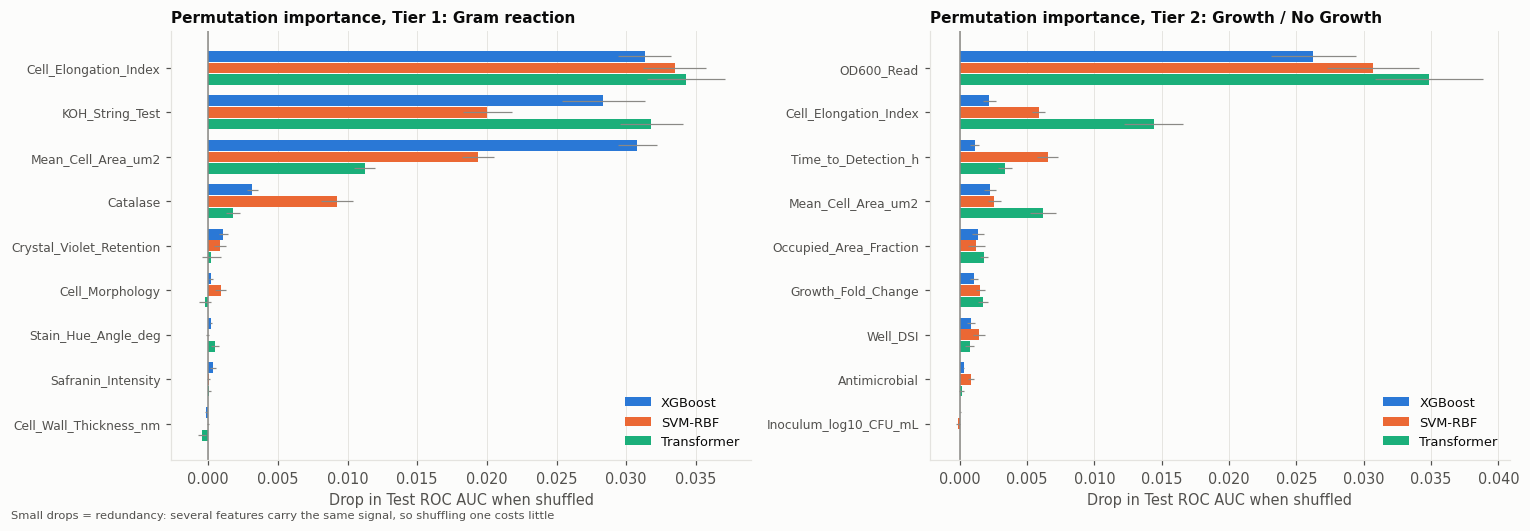

In [15]:
perm = em.permutation_table(cascades, sets["Test"])
em.plot_permutation(perm)
perm.pivot_table(index=["tier", "feature"], columns="Model", values="auc_drop_mean").round(4)

**Reading the results**

* Tier 1 and Tier 2 clear every threshold on Test for all three models, and Train and Test stay within about 0.015 of each other.
* Pooling the well images of an isolate makes the isolate-level Gram call perfect on Test, so no Gram-positive series loses its MIC in the cascade.
* Tier 3: EA is 100% for all three models; CA is 98-100%; there are no VMEs or MEs on Test. Exact agreement (AA) is the hardest endpoint because it depends on the single well at the MIC step. SVM-RBF reaches 0.970 and XGBoost 0.949, while the Transformer (0.899) misses the 0.92 AA target.
* Permutation importance is small for each single feature because several growth readouts carry the same signal; shuffling one leaves the others.

In [16]:
_ = em.run(); plt.close("all")        # write all tables and figures (as `make evaluate`)
from src.models import predict_model as pm
_ = pm.main()                             # write reports/predictions/*.csv (as `make predict`)

13:41:45 | INFO    | src.models.evaluate_model | Train/Test comparison:
| Tier | Metric | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test | Transformer Train | Transformer Test |
|---|---|---:|---:|---:|---:|---:|---:|
| Tier 1 Gram | Accuracy | 0.980 | 0.973 | 0.972 | 0.968 | 0.968 | 0.968 |
| Tier 1 Gram | Sensitivity | 0.967 | 0.966 | 0.971 | 0.971 | 0.952 | 0.959 |
| Tier 1 Gram | Specificity | 0.995 | 0.981 | 0.973 | 0.963 | 0.987 | 0.980 |
| Tier 1 Gram | PPV | 0.995 | 0.985 | 0.977 | 0.971 | 0.989 | 0.983 |
| Tier 1 Gram | NPV | 0.961 | 0.959 | 0.965 | 0.963 | 0.945 | 0.950 |
| Tier 1 Gram | AUC | 0.999 | 0.996 | 0.997 | 0.994 | 0.997 | 0.994 |
| Tier 1 Gram | F1 | 0.981 | 0.975 | 0.974 | 0.971 | 0.970 | 0.971 |
| Tier 2 Growth | Accuracy | 0.994 | 0.985 | 0.989 | 0.983 | 0.990 | 0.979 |
| Tier 2 Growth | Sensitivity | 0.996 | 0.989 | 0.990 | 0.987 | 0.992 | 0.983 |
| Tier 2 Growth | Specificity | 0.992 | 0.980 | 0.987 | 0.979 | 0.987 | 0.975 |
| Tier 2 Growth | PPV 

13:41:45 | INFO    | src.models.evaluate_model | Acceptance (Test): 56/57 criteria met


13:41:46 | INFO    | src.models.predict_model | Scored 1540 wells from test.csv -> 165 isolate Gram calls, 297 MIC calls (all models) in /home/claude/gram-id-ast-ml/reports/predictions
